# Apresentação ✒️

Exemplo de implementação da criação de um Agent que faz modelos de perguntas e respostas, em formato de questões de prova, para automatizar o processo da criação dessas para ser utilizado por uma possível plataforma de estudos para exames preparatórios



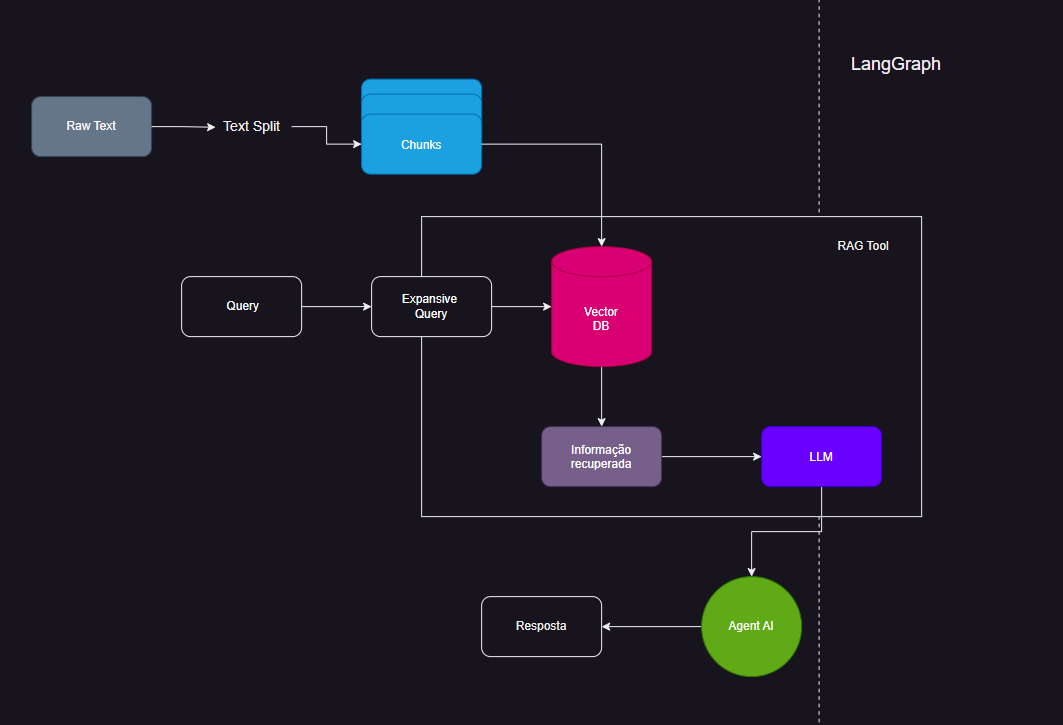

## Biblioteca 📚

In [1]:
!pip install langgraph -q
!pip install langchain -q
!pip install langchain-community -q
!pip install langchain_google_genai -q
!pip install langchain-core -q
!pip install google-generativeai -q
!pip install sentence_transformers -q
!pip install chromadb -q
!pip install pypdf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 836.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.2/407.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.0/378.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/4

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ==============================
# 1. Bibliotecas padrão do Python
# ==============================
import os
import operator
import textwrap
import getpass
from typing import Type, List, TypedDict, Annotated

# ==============================
# 2. Bibliotecas de terceiros
# ==============================
from pydantic import BaseModel, Field
from IPython.display import Markdown
from sentence_transformers import CrossEncoder
from pypdf import PdfReader

# ==============================
# 3. Bibliotecas específicas de IA e LangChain
# ==============================
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

from langchain_community.vectorstores import Chroma
from langchain_community.tools.tavily_search import TavilySearchResults

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    SentenceTransformersTokenTextSplitter,
)

from langchain import PromptTemplate
from langchain.chains import LLMChain
from langchain.agents import AgentExecutor

# ==============================
# 4. Bibliotecas específicas do LangGraph
# ==============================
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# ==============================
# 5. Módulos e mensagens do LangChain Core
# ==============================
from langchain_core.tools import tool, BaseTool
from langchain_core.messages import (
    AnyMessage, SystemMessage, HumanMessage, ToolMessage
)


## Variáveis de ambiente 🧩

In [4]:
os.environ["GOOGLE_API_KEY"] = getpass.getpass()

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

··········


In [5]:
llm = ChatGoogleGenerativeAI(
    model = 'gemini-1.5-pro-latest',
    temperature=0.2)

In [6]:
# Testando a conexão com o Gemini.

llm.invoke('Diga-me em uma frase sobre o que a música On Melancholy Hill da banda Gorilazz fala').content

'"On Melancholy Hill" do Gorillaz é uma canção sobre encontrar consolo e esperança em um lugar inesperado com alguém que você ama, mesmo em tempos de conflito e incerteza. \n'

## Ferramenta ⚙️

Os Agents AI são criados junto de suas ferramentas, sendo os componentes com os quais permitem os modelos interagir com o meio, colhendo ou imprimindo informação. No caso dos Agents AI baseados em modelos de linguagem, é o uso dessas que permite que uma aplicação deixe de ser apenas um chatbot, para ser um Agent.

A ferramenta elaborada será um sistema de Advanced RAG, que será responsável por realizar consultas em um banco de dados vetorial, a fim de recuperar informações relevantes a partir de uma consulta do usuário, por meio das quais o Agent irá elaborar modelos de pergunta e resposta, segundo uma formatação de prova.

Para a criação da ferramenta, primeiramente irei extrair o texto do PDF, dividi-lo em chunks e, assim, inseri-lo no vector db.

#### Extraindo o texto

In [7]:
file_path = ['/content/Apostila/caderno_linguagens_e_seus_codigos.pdf']

# Lista que conterá todos os arquivos lidos.
all_text = []

# Iterando sobre os arquivos a fim de realizar a leitura de cada qual.
for file_path in file_path:

  # Lê os arquivos em PDF.
  reader = PdfReader(file_path)

  # Extrai os textos lidos.
  text_extract = [p.extract_text() for p in reader.pages]

  # Extrai somente os textos, desconsiderando espaços em branco.
  text = [text for text in text_extract if text]

  # Armazena os textos como um todo extraídos na lista all_text.
  all_text.extend(text)


In [8]:
len(all_text)

240

#### Dividindo em chunks

In [9]:
# Primeira divisão por lotes de texto.
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=150,
    length_function=len,
    separators=['\n\n', '\n', '.', ' ', '']
    )

text_splitted_rc = recursive_splitter.split_text('\n\n'.join(all_text))

In [10]:
len(text_splitted_rc)

364

In [11]:
# Segunda divisão por tokens.

# O diferencial desse 'splitter' em relação ao anterior é que ele
# busca realizar as divisões no texto, formando os chunks, de modo
# a manter a relevância semântica de cada chunk, sendo construído
# com base em um modelo de sentence-transformers.

token_splitter = SentenceTransformersTokenTextSplitter(
    tokens_per_chunk=384,
    chunk_overlap=0
)

token_split_text = []

for text in text_splitted_rc:

  token_split_text += token_splitter.split_text(text)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
len(token_split_text)

642

## Inserção do texto no banco de dados vetorial

In [13]:
# Instanciando o modelo de embedding utilizado.

embedding_function = SentenceTransformerEmbeddingFunction()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
# Criando o objeto chroma_client, que me permitirá interagir com o ChromaDB.

chroma_client = chromadb.Client()

# Criando o banco de dados vetorial. Para isso, define-se seu nome e o modelo
# de embedding de uso.

chroma_db = chroma_client.create_collection(name = 'Literatura_para_o_vestibular',
                                            embedding_function = embedding_function)

In [15]:
# Gerando uma lista de identificação para cada porção
# presente no meu banco de dados vetorial.

ids = [str(i) for i in range(len(token_split_text))]

In [16]:
%%time

# Adicionando os documentos ao banco de dados vetorial
# junto de cada identificação.
chroma_db.add(ids = ids,
              documents = token_split_text)

CPU times: user 1min 23s, sys: 6.35 s, total: 1min 29s
Wall time: 1min 30s


In [17]:
# Verificando a quantidade de itens no banco de dados vetorial.

chroma_db.count()

642

#### Advanced RAG Tool

In [18]:
def argument_multiple_query(query, model = llm) -> str:

  # Ferramenta que realiza a consulta expandida,
  # com base na query do usuário. Por meio dela a
  # o contexto de busca é expandido, melhorando
  # a recuperação de informações presentes no banco
  # de dados vetorial.

  template = PromptTemplate(
      input_variables=['query'],
      template='''
      You are an experienced is an experienced researcher on topics related the
      brazilian literature for brazilian entrance exams.

      You need to develop questions for a Retrieval Argumented Generation system,
      so that they serve the expansive query approach. The objective of this approach is,
      based on the user's query, to create a certain number of questions that help to
      retrieve relevant information from documents stored in the vector database,
      so that they enable the provision of accurate answers to the user.

      Therefore, suggest up to 10 additional related questions
      to help them find the information they need for the provided question.
      Suggest only short questions without compound large sentences.
      Output one question per line.

      If the {query} does not match with themes related brazilian literature,
      you MUST SUGGEST THIS response : ""The query performed is not present in the
      knowledge base. There are only themes related to Brazilian literature required
      for Brazilian entrance exams""

      Question: {query}

      Helpful questions:
      '''  )

  chain = LLMChain(llm=model, prompt=template)
  response = chain.run(query=query)

  return response

In [19]:
def retriever_tool(query : str,
                   expansive_query_function = argument_multiple_query) -> list:

  # Ferramenta que realiza a recuperação da informação contidas nos vetores
  # dispostos no banco de dados vetorial, por meio da consulta expandida.
  # Além disso, ela efetua o re-ranqueamento dos documentos extraídos, retornando
  # apenas top 5 mais relevantes.

  # Criando a consulta expandida.
  expanded_query = f'{query} {expansive_query_function()}'

  # Recuperando a informação no banco de dados vetorial.
  results = chroma_db.query(query_texts=expanded_query,
                            n_results=10,
                            include=['documents', 'embeddings'])

  # Armazenando numa variável os documentos recuperados.
  retrieved_documents = results['documents'][0]

  return retrieved_documents

In [20]:
def rerank_tool(query : str, docs : list) -> list:

  # Instanciando o cross encoder, utilizado para o re-ranqueamento.
  cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

   # Colocando em par a consulta e cada documento recuperado.
  pairs = [[query, doc] for doc in retriever_tool()]

  # Pontuando os documentos, com uma predição do cross encoder.
  scores = cross_encoder.predict(pairs)

  # Listando os documentos juto de suas pontuações.
  documents_with_scores = list(zip(retriever_tool(), scores))

  # Ordenando os documentos da melhor pontuação para a pior.
  ranked_documents = sorted(documents_with_scores, key=lambda x: x[1],
                                reverse=True)

  # Selecionando apenas os 5 documentos mais relevantes.
  top5_re_ranked_documents = [doc for doc, score in ranked_documents[:5]]

  return top5_re_ranked_documents

In [21]:
def response_with_rag(query : str, docs = rerank_tool,
                      model = llm) -> str:

  # Ferramenta que realiza a resposta da consulta do usuário, com base no RAG
  # realizado. Caso a consulta dista muito dos documentos recuperados, ela é instruída
  # a informar que o termo consultado foge o escopo de seu domínio de conhecimento.
  # Caso o termo de consulta não tenha match com o que fora recuperado, mas ainda faça
  # parte do seu domínio, instrui o Agent a realizar a pesquisa na internet, por meio
  # da ferramenta Tavily.

  information = '\n\n'.join(rerank_tool())

  prompt_template = PromptTemplate(
      input_variables = ['query', 'information'],
      template = '''
      You are an experienced teacher specializing in brazilian literature for brazilian entrance exams.

      Your task is to read the information retrieved and prepare a cohesive text that
      can be used to prepare questions and answers templates for the Agent who asks brazilian literature questions
      for the entrance exam.

      If the query does not align with the information available, you MUST recommend
      that the Agent used say to the user's {query} is out of your knowledge base.

      Query: {query}
      Information: {information}

      Cohesive text:
      ''')

  chain = LLMChain(llm = model, prompt = prompt_template)
  response = chain.invoke(input={'query':query, 'information':information})

  return response

In [22]:
@tool
def rag_tool(query : str) -> str:

    # Ferramenta de RAG propriamente dita, construída por meio da combinação
    # de cada ferramenta importante para a sua realização. A sua construção
    # segue o template exigido para a criação de ferramentas próprias ao criar
    # Agents AI com LangChain e LangGraph.

    '''Use this for realize searchs in vector database for retrieval argumented generation'''

    expanded_query_return = argument_multiple_query(query)
    retrieval_information = retriever_tool(query)
    retrieval_docs = rerank_tool(query)
    rag_tool_response = response_with_rag(query)

    return rag_tool_response

## Agents AI 🤖

In [23]:
# Criando o componente State, responsável pela
# persistência de informação na arquitetura de grafos.

class AgentState(TypedDict):
  messages : Annotated[list[AnyMessage], operator.add]

In [24]:
# Criando um sistema de memória a partir do qual
# possibilitará ao Agent manter a persistência dos
# dados (informação) gerados junto da interação
# com o usuário.

memory = MemorySaver()

In [ ]:
memory

In [25]:
class AgentTeacher:

  def __init__(self, model, tools, checkpointer, system = ''):

    # Construindo os atributos presentes no Agent.

    self.system = system

    # Criando a arquitetura em grafos.

    graph = StateGraph(AgentState)

    # Adicionando o grafo llm e action, por meio dos métodos
    # call_gemini e take_action, respectivamente.
    graph.add_node('llm', self.call_gemini)
    graph.add_node('action', self.take_action)


    # Define o fluxo entre nós de forma condicional, de modo que
    # após o nó 'llm' a função exists_actions é avaliada para ver
    # se o fluxo continua ou para.
    graph.add_conditional_edges(
        'llm',
        self.exists_actions,
        {True : 'action', False : END}
    )

    # Vinculando o nó 'llm', com o nó 'action'.
    graph.add_edge('action', 'llm')

    # Definindo o ponto de entrada no grafo, que é o llm.
    graph.set_entry_point('llm')

    self.graph = graph.compile(checkpointer = checkpointer) # Persistindo a memória no grafo.
    self.tools = {tool.name : tool for tool in tools}       # Organizando as ferramentas em dicionário.
    self.model = model.bind_tools(tools)                    # Vinculando as ferramentas ao modelo.

  def exists_actions(self, state : AgentState):

    # Função que analisa se há a necessidade de realizar
    # ações existentes, a partir da vericação da última mensagem
    # do dicionário state, por meio de uma operação booleana.

    # Se há funções de chamada, o valor é True, mantendo
    # a ação; se não, finalizasse a ação.

    result = state['messages'][-1]
    return len(result.tool_calls) > 0

  def call_gemini(self, state: AgentState):

    # Função que chama o modelo de linguagem (LLM)
    # para gerar respostas com base nas mensagens atuais
    # do estado presente.

    # Atribui as mensagens no estado à variável messages.

    messages = state['messages']

    if self.system:

      # Se há um sistema, cria uma nova lista de mensagens,
      # contendo uma única SystemMessage como o conteúdo do sistema.

      messages = [SystemMessage(content = self.system)] + messages

    # Invoca o modelo para gerar uma nova mensagem,
    # que gera e retorna um novo estado com a nova
    # mensagem gerada.

    message = self.model.invoke(messages)
    return {'messages': [message]}

  def take_action(self, state: AgentState):

    # Função que executa as ações determinadas em tool_calls
    # e atualiza o estado com o resultado das ações.

    # Extrai as chamadas das ferramentas da última mensagem
    # do estado.

    tool_calls = state['messages'][-1].tool_calls

    # Cria-se uma lista para armazenar o resultado das ações.

    results = []

    # Cria um ciclo iterativo para verificar a qualidade da
    # ferramenta e realizar o tratamento de erros, além de retornar
    # a ferramenta utilizada, no que se refere ao seu id, nome e conteúdo.

    for tool in tool_calls:
      print(f'Calling: {tool}')
      if not tool['name'] in self.tools:      # check for bad tool name from LLM
        print('\n ....bad tool name....')
        result = 'bad tool name, retry'  # instruct LLM to retry if bad
      else:
        result = self.tools[tool['name']].invoke(tool['args'])
        results.append(ToolMessage(tool_call_id=tool['id'],
                                       name=tool['name'],
                                       content=str(result)))

        # Atualiza o estado com os resultados das ações
        state['messages'].extend(results)
        print('Back to the model!')

        return {'messages': state['messages']}

In [26]:
# Definindo a(s) ferramenta(s) utilizada(s)

tools = [rag_tool]

In [27]:
system_prompt = ('''
                 You are an experienced teacher specializing in Brazilian literature,
                 focused on preparing students for entrance exams.

                 Your task is to **create three questions** and **answers according to each question**
                 based on the information provided, following the **standard format of entrance exams**
                 for higher education admission.

                 # Instructions for the Agent:
                 1. **Carefully read the provided text** and create **three questions** and
                    **answers for each question** that align with the expected format and difficulty
                    for entrance exams.

                 2. Each question must be **labeled with a difficulty tag**: (easy), (medium), or (hard).
                 - **Easy questions (easy):** Should be answered through **direct interpretation of the text**.
                 - **Medium questions (medium):** Require **a good understanding of the text**, but can still be
                     answered through interpretation.
                 - **Hard questions (hard):** Must **demand deep knowledge of the text**, requiring well-prepared
                     and more complex responses.

                 USE this example for you learning how you MUST do the questions.

                Text used as a basis for preparing questions :

                [
                Estou sem palavras…
                Anseio dizer tudo, mas não consigo
                As palavras se furtam e qualquer nome
                Que penso utilizar para expressar o meu sentimento
                Presente se desfazem, como neve ao vento,
                Ao passo que parecem pobres ou rasas,
                Incapazes de exprimir o que meu coração está a sentir

                Choro…,
                Com pulsos que pulsam como um pulsar,
                Meu coração pulsa e minhas lágrimas desatam,
                Carregando o intento de minhas invisíveis palavras,
                Dos meus sentimentos e de minha presente dor,
                Do amor concebido e, principalmente, de sua falta…,

                O verdadeiro amor é aquele no qual à pessoa amada
                Desejamos dizer um eterno olá, incapaz de findar
                Quando temos dificuldade de dizer adeus ou sequer um até mais,
                Pois tememos, em um piscar de olhos, perdê-lo de nossa vida
                De nosso olhar, de nossas mãos e de nossa existência,
                Frente à entropia do tempo que tudo ao pó tenciona retornar

                As folhas caem,
                E o som do universo ao meu ouvido escuto ressoar
                “ Tudo se esvai, jovem Werther, e o que uma vez fora
                É impedido de ao outrora retornar
                O passado é inerte, o presente uma ilusão
                E o futuro um local de esperada instanciação,
                Havendo apenas um elemento constante e inamovível,
                Que é a causa e o fim do movimento de toda criação

                Eterno e sem angústia, exceto no temor de sua perda,
                Preso na limitação entre o ser e o não-ser,
                Repentino como a percepção da existência de uma singularidade,
                Que produz uma deliciosa risada oculta e que docemente mareja os olhos
                Que é rápido. Agora. Aqui. Agora e sempre!
                E que a partir do instante de sua criação se estende ao antes e ao depois,
                O qual uma vez criado e cristalizado jamais desfalece,
                Sendo capaz de irromper as barreiras do tempo e do espaço,
                Que semelhante à uma chama viva e irredutível, acima das leis da físicas se estabelece…! “
                O que é esse elemento senão o amor ?
                Elemento para o qual vivemos e buscamos,
                Capaz de nos prover a verdadeira existência e conexão
                De vencer uma mera existência axiomática e fantasmagórica,
                Um sopro de vida em vão, de modo que à medida que somos consumidos pela quarta dimensão,
                Passamos a compreender a única…, verdadeira… e real questão...,
                """

                *Example easy question* :
                """
                (easy)
                Qual é o sentimento predominante expressado pelo eu-lírico ao longo do texto?

                **Expected answer (Easy):**
                O eu-lírico expressa tristeza, melancolia e uma profunda sensação de falta e amor ausente.
                """

                *Example medium question* :
                """
                (medium)
                No trecho 'as palavras se furtam e qualquer nome [...] se desfazem, como neve ao vento',
                o autor faz uso de uma figura de linguagem. Qual é essa figura e como ela contribui para
                a expressão do sentimento?

                **Expected answer (Medium):**
                O trecho utiliza uma metáfora, comparando a dificuldade de verbalizar sentimentos à neve que
                se desfaz ao vento. Isso enfatiza a fragilidade da profundidade das palavras
                e a dificuldade em expressar emoções complexas ao seu interlocutor.
                """

                *Example difficult question* :
                """
                (hard)
                Explique o conceito de 'entropia do tempo' presente no texto e sua relação com a ideia de amor
                apresentada. Como o autor utiliza esse conceito para explorar a passagem do tempo e o valor do amor?

                **Expected answer (Hard):**
                O conceito de "entropia do tempo" remete à inevitabilidade da passagem do tempo e à desordem
                crescente que afeta tudo. O texto sugere que o amor é um elemento capaz de transcender essa inevitabilidade,
                permanecendo constante e imutável. Dessa forma, o amor se torna uma força que desafia o tempo, resistindo
                à transitoriedade e ao esquecimento.
                ]

                For you created the questions and answers for each question, You MUST ONLY USE the {tools}
                for respond the user's query accordily the example above provided.

                If the user’s question is OUTSIDE the scope of brazilian literature,
                you MUST EXPLICITLY state that you DO NOT dominate the theme about the question
                and is better he search for another Agent System.

                When responding to user queries, use the {tools} as necessary,
                following the format below:

                Thought: Do I need to use a tool? Yes
                Action: the action to take, should be one of [{tool_names}]
                Action Input: the input to the action
                Observation: the result of the action

                When you have the answer, or if no tool is required, use the following format:
                Thought: Do I need to use a tool? [your response here]

                Answer the user's query and in portuguese.

                Final Answer: [your response here]
                ''')

In [29]:
# Instanciando o Agent.

agent = AgentTeacher(model       = llm,
                    tools        = tools,
                    checkpointer = memory,
                    system       = system_prompt)

In [33]:
start_text_template = 'Elabore modelos de 3 perguntas e resposta para cada uma sobre :'

In [34]:
query_1 = f'{start_text_template} O Realismo no Brasil'

query_2 = f'{start_text_template} As influências desse movimento'

query_3 = f'{start_text_template} Em qual período Machado de Assis se enquadra na literatura brasileira'

query_4 = f'{start_text_template} Diferença do realismo em relação ao naturalismo'

query_5 = 'Qual foi a primeira pergunta ?'

query_6 = 'Qual banda toca On Melancolic Hill ?'

## Realizando as consultas 🤔

In [31]:
%%time

messages = [HumanMessage(content = query_1)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: ##  Perguntas sobre Realismo no Brasil:
**(Fácil)**  1. **Qual movimento literário antecedeu o Realismo no Brasil e quais características os
diferenciam?**  **Resposta:** O Romantismo precedeu o Realismo no Brasil. Enquanto o Romantismo se
caracterizava pela idealização do amor, da mulher e da pátria, com heróis idealizados e forte
subjetividade, o Realismo buscava retratar a realidade de forma objetiva e crítica

In [35]:
%%time

messages = [HumanMessage(content = query_2)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: ## Perguntas sobre as Influências do Realismo no
Brasil:  **(Fácil)**  1. **O Realismo brasileiro sofreu forte influência de um movimento artístico e
literário europeu que buscava retratar a realidade de forma objetiva e crítica. Qual é o nome desse
movimento?**  **Resposta:** O Realismo brasileiro foi fortemente influenciado pelo
**Realismo/Naturalismo europeu**, movimento que buscava romper com o Romantismo e r

In [36]:
%%time

messages = [HumanMessage(content = query_3)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: ## Perguntas sobre a inserção de Machado de
Assis na Literatura Brasileira:  **(Fácil)**  1. **Machado de Assis é frequentemente associado a
qual movimento literário brasileiro, conhecido por sua busca por retratar a realidade de forma
objetiva e crítica?**  **Resposta:** Machado de Assis é considerado o maior expoente do **Realismo**
brasileiro.   **(Média)**  2. **Apesar de ser considerado um autor realista, a 

In [37]:
%%time

messages = [HumanMessage(content = query_4)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: ## Perguntas sobre as diferenças entre Realismo
e Naturalismo:  **(Fácil)**  1. **Apesar de frequentemente relacionados, Realismo e Naturalismo são
movimentos distintos. Enquanto o Realismo busca retratar a realidade de forma objetiva, qual é a
principal característica do Naturalismo?**  **Resposta:** O Naturalismo radicaliza a proposta do
Realismo, buscando uma explicação determinista para o comportamento humano

In [38]:
%%time

messages = [HumanMessage(content = query_5)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: Você solicitou modelos de perguntas sobre
diversos temas relacionados ao Realismo e Naturalismo. Para ser mais preciso, qual dos conjuntos de
perguntas você gostaria de revisitar?  A primeira pergunta de qual tema?   Por favor, me diga o tema
para que eu possa indicar a primeira pergunta elaborada. 😊
CPU times: user 35.8 ms, sys: 2.27 ms, total: 38 ms
Wall time: 2.16 s


In [39]:
%%time

messages = [HumanMessage(content = query_5)]
thread = {"configurable": {"thread_id": "22"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer: Você ainda não me forneceu nenhum texto como
base para a criação de perguntas. Por favor, compartilhe o texto para que eu possa elaborar as
questões.
CPU times: user 24.4 ms, sys: 2.95 ms, total: 27.4 ms
Wall time: 1.4 s


In [40]:
%%time

messages = [HumanMessage(content = query_6)]
thread = {"configurable": {"thread_id": "10"}}

for event in agent.graph.stream({"messages": messages}, thread):
    for v in event.values():
        for message in v['messages']:
          content = message.content
          formatted_content = '\n'.join(textwrap.wrap(content, width=100))
          print(formatted_content)

{'name': 'rag_tool', 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'parameters': {'type_': 6, 'description': 'Use this for realize searchs in vector database for retrieval argumented generation', 'properties': {'query': {'type_': 1, 'format_': '', 'description': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0', 'properties': {}, 'required': []}}, 'required': ['query'], 'format_': '', 'nullable': False, 'enum': [], 'max_items': '0', 'min_items': '0'}}
Thought: Do I need to use a tool? No  Final Answer:  Eu sou especialista em literatura brasileira,
não domino o tema sobre músicas de bandas. É melhor você procurar por outro sistema de agente. 😊
CPU times: user 29.5 ms, sys: 418 µs, total: 29.9 ms
Wall time: 1.52 s
